In [65]:
cpu_percent = psutil.cpu_percent(interval=1)

In [66]:
from pyspark.sql import SparkSession
import pyspark.sql.functions as F
import matplotlib.pyplot as plt
import psutil
import pyspark
import pandas as pd
import numpy as np
from collections import Counter
import re

print(f"Persentase penggunaan CPU: {cpu_percent}%")


Persentase penggunaan CPU: 26.5%


In [67]:
spark = SparkSession.builder \
    .appName("Bali Popular Destination for Tourist 2022 Analysis") \
    .getOrCreate()

print(f"Persentase penggunaan CPU: {cpu_percent}%")

Persentase penggunaan CPU: 26.5%


In [69]:
df = spark.read.csv('Bali Popular Destination for Tourist 2022 - Sheet1.csv', header=True, inferSchema=True)
df.show(df.count(), truncate=False)

print(f"Persentase penggunaan CPU: {cpu_percent}%")


+----------------------------------+----------------------------------------------------------------------------------------------------------------------------------+---------------------------------+---------------------+----------------------+---------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------+----------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------+-------------------

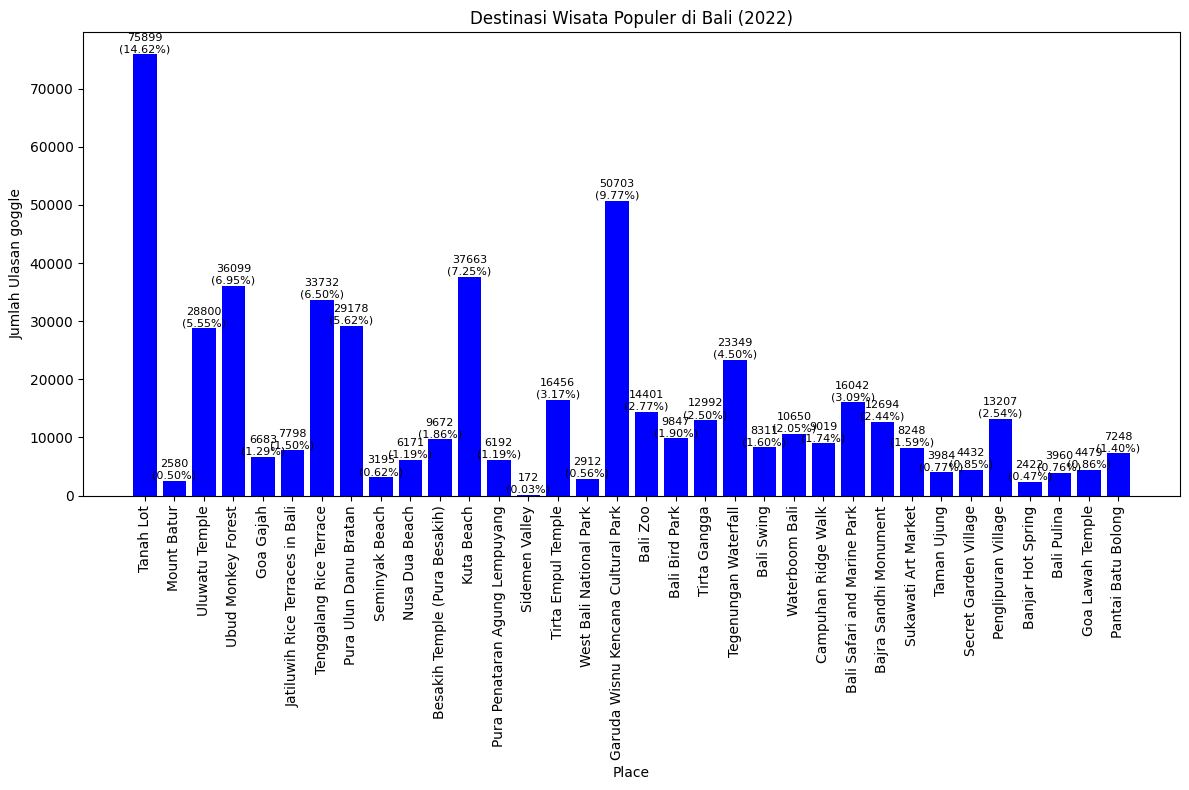

Persentase penggunaan CPU: 37.9%


In [70]:
import pandas as pd
import matplotlib.pyplot as plt

file_path = 'C:/Users/ameli/Documents/Semester 4/PEMPAR/tubes pempar/tubes pempar/Bali Popular Destination for Tourist 2022 - Sheet1.csv'
bali_data = pd.read_csv(file_path)

places = bali_data['Place']
reviews = bali_data['Google Reviews (Count)']

plt.figure(figsize=(12, 8))
bars = plt.bar(places, reviews, color='blue')

total_reviews = reviews.sum()
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width() / 2, yval, f'{yval}\n({yval / total_reviews:.2%})', ha='center', va='bottom', fontsize=8)


plt.xlabel('Place')
plt.ylabel('Jumlah Ulasan goggle')
plt.title('Destinasi Wisata Populer di Bali (2022)')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

print(f"Persentase penggunaan CPU: {cpu_percent}%")

In [71]:
df.select("Place", "Location").show(df.count(), truncate=False)

print(f"Persentase penggunaan CPU: {cpu_percent}%")

+----------------------------------+----------------------------------------------------------------------------------------------------------------------------------+
|Place                             |Location                                                                                                                          |
+----------------------------------+----------------------------------------------------------------------------------------------------------------------------------+
|Tanah Lot                         |Beraban, Kec. Kediri, Kabupaten Tabanan, Bali 82121                                                                               |
|Mount Batur                       |Bangli Regency, Bali, Indonesia                                                                                                   |
|Uluwatu Temple                    |Uluwatu (South Kuta, Badung)                                                                                                

In [24]:
from pyspark.sql import SparkSession

spark = SparkSession.builder.appName("BaliDestinations").getOrCreate()

file_path = 'C:/Users/ameli/Documents/Semester 4/PEMPAR/tubes pempar/tubes pempar/Bali Popular Destination for Tourist 2022 - Sheet1.csv'
df_bali = spark.read.csv(file_path, header=True, inferSchema=True)

df_bali.select("Place", "Google Reviews (Count)").show(df_bali.count(), truncate=False)

print(psutil.cpu_percent())


+----------------------------------+----------------------+
|Place                             |Google Reviews (Count)|
+----------------------------------+----------------------+
|Tanah Lot                         |75899.0               |
|Mount Batur                       |2580.0                |
|Uluwatu Temple                    |28800.0               |
|Ubud Monkey Forest                |36099.0               |
|Goa Gajah                         |6683.0                |
|Jatiluwih Rice Terraces in Bali   |7798.0                |
|Tenggalang Rice Terrace           |33732.0               |
|Pura Ulun Danu Bratan             |29178.0               |
|Seminyak Beach                    |3195.0                |
|Nusa Dua Beach                    |6171.0                |
|Besakih Temple (Pura Besakih)     |9672.0                |
|Kuta Beach                        |37663.0               |
|Pura Penataran Agung Lempuyang    |6192.0                |
|Sidemen Valley                    |172.

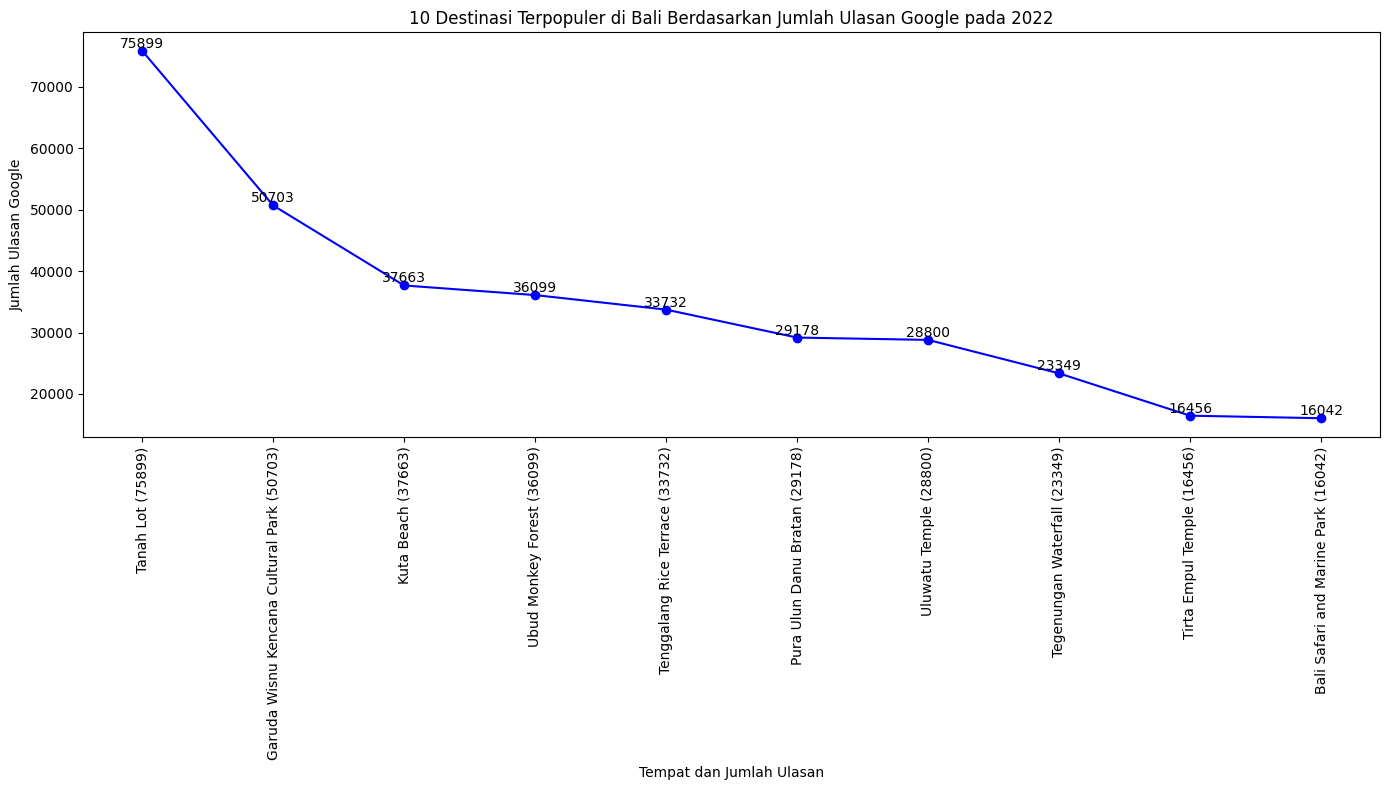

CPU usage percentage: 14.5


In [36]:
file_path = 'C:/Users/ameli/Documents/Semester 4/PEMPAR/tubes pempar/tubes pempar/Bali Popular Destination for Tourist 2022 - Sheet1.csv'
df_bali = pd.read_csv(file_path)

top_places = df_bali[['Place', 'Google Reviews (Count)']].sort_values(by='Google Reviews (Count)', ascending=False).head(10)

top_places['Place and Reviews'] = top_places.apply(
    lambda row: f"{row['Place']} ({row['Google Reviews (Count)']})", axis=1)

# Buat plot garis
plt.figure(figsize=(14, 8))
plt.plot(top_places['Place and Reviews'], top_places['Google Reviews (Count)'], marker='o', linestyle='-', color='blue')

# Tambahkan teks ke setiap titik pada grafik
for i, (place, reviews) in enumerate(zip(top_places['Place and Reviews'], top_places['Google Reviews (Count)'])):
    plt.text(i, reviews, f'{reviews}', ha='center', va='bottom', fontsize=10)

# Tambahkan label dan judul
plt.xlabel('Tempat dan Jumlah Ulasan')
plt.ylabel('Jumlah Ulasan Google')
plt.title('10 Destinasi Terpopuler di Bali Berdasarkan Jumlah Ulasan Google pada 2022')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

# Cetak persentase penggunaan CPU saat ini
print("CPU usage percentage:", psutil.cpu_percent())


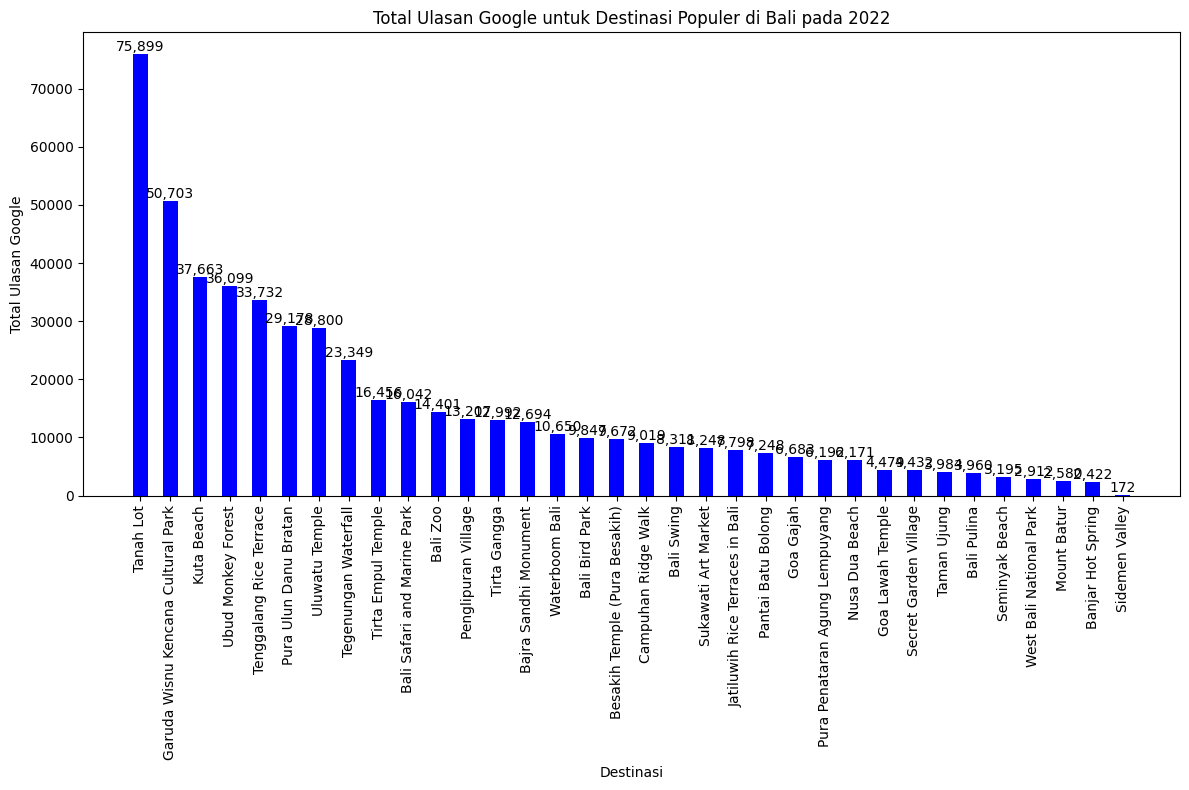

16.3


In [27]:
# Membaca data dari CSV yang sudah dibersihkan
data = pd.read_csv('bali_destinations_cleaned.csv')

# Menyortir data berdasarkan jumlah ulasan Google (descending)
data = data.sort_values(by='Google Reviews (Count)', ascending=False)

# Membuat plot
plt.figure(figsize=(12, 8))
x = range(len(data['Place']))
bars = plt.bar(x, data['Google Reviews (Count)'], width=0.5, color='blue')

# Menambahkan label di atas setiap batang
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width() / 2, height, f'{int(height):,}', ha='center', va='bottom')

# Membuat label dan judul
plt.xlabel('Destinasi')
plt.ylabel('Total Ulasan Google')
plt.title('Total Ulasan Google untuk Destinasi Populer di Bali pada 2022')

# Membuat penanda label pada sumbu x
plt.xticks([p for p in x], data['Place'], rotation=90)

# Menyesuaikan tata letak plot
plt.tight_layout()

# Menampilkan plot
plt.show()

print(psutil.cpu_percent())

In [38]:
# Fungsi untuk membaca file CSV dan mengambil semua teks
def read_csv(file_path):
    df = pd.read_csv(file_path)
    # Menggabungkan semua nilai dari dataframe ke dalam satu teks
    all_text = " ".join(df.astype(str).values.flatten())
    return all_text

# Fungsi untuk menghitung jumlah kemunculan setiap kata dalam teks
def word_count(text):
    words = re.findall(r'\b\w+\b', text)  # Menghapus karakter non-alfanumerik dan membagi berdasarkan spasi
    return Counter(words)

# Path ke file CSV
file_path = r'Bali Popular Destination for Tourist 2022 - Sheet1.csv'

# Baca konten file CSV
all_text = read_csv(file_path)

# Lakukan word count pada teks
text_word_count = word_count(all_text)

# Tampilkan 10 kata yang paling sering muncul
most_common_words = text_word_count.most_common(10)
for word, count in most_common_words:
    print(f'{word}: {count} kali')

# Simpan hasil word count ke dalam file CSV
output_file = 'word_count_results.csv'
with open(output_file, 'w', newline='', encoding='utf-8') as csvfile:
    writer = csv.writer(csvfile)
    writer.writerow(['Word', 'Count'])
    writer.writerows(text_word_count.items())

print(f"Hasil word count telah disimpan dalam file: {output_file}")

print("CPU usage percentage:", psutil.cpu_percent())


8: 106 kali
Bali: 74 kali
115: 64 kali
the: 58 kali
000: 52 kali
USD: 49 kali
4: 47 kali
IDR: 43 kali
for: 40 kali
a: 39 kali
Hasil word count telah disimpan dalam file: word_count_results.csv
CPU usage percentage: 17.4


In [58]:
import pandas as pd
from collections import Counter
import re

# Fungsi untuk membaca file CSV dan mengambil semua teks
def read_csv(file_path):
    df = pd.read_csv(file_path)
    # Menggabungkan semua nilai dari dataframe ke dalam satu teks
    all_text = " ".join(df.astype(str).values.flatten())
    return all_text

# Fungsi untuk menghitung jumlah kemunculan setiap kata dalam teks
def word_count(text):
    words = re.findall(r'\b\w+\b', text)  # Menghapus karakter non-alfanumerik dan membagi berdasarkan spasi
    return Counter(words)

# Path ke file CSV
file_path = r'Bali Popular Destination for Tourist 2022 - Sheet1.csv'

# Baca konten file CSV
all_text = read_csv(file_path)

# Lakukan word count pada teks
text_word_count = word_count(all_text)

# Simpan hasil word count ke dalam DataFrame pandas
df_word_count = pd.DataFrame(list(text_word_count.items()), columns=['Word', 'Count'])

# Tampilkan 10 kata yang paling sering muncul
most_common_words = df_word_count.nlargest(10, 'Count')

# Simpan hasil word count ke dalam file CSV
output_file = 'word_count_results.csv'
df_word_count.to_csv(output_file, index=False, encoding='utf-8')

print("10 kata yang paling sering muncul:")
print(most_common_words.to_string(index=False))

print("CPU usage percentage:", psutil.cpu_percent())

10 kata yang paling sering muncul:
Word  Count
   8    106
Bali     74
 115     64
 the     58
 000     52
 USD     49
   4     47
 IDR     43
 for     40
   a     39
Hasil word count telah disimpan dalam file: word_count_results.csv
CPU usage percentage: 29.6


In [56]:
import pandas as pd
from collections import Counter
import re

# Baca konten file CSV dan gabungkan semua teks menjadi satu
def read_csv(file_path):
    df = pd.read_csv(file_path)
    return " ".join(df.astype(str).values.flatten())

# Hitung jumlah kemunculan setiap kata dalam teks
def word_count(text):
    words = re.findall(r'\b\w+\b', text)
    return Counter(words)

# Path ke file CSV
file_path = 'Bali Popular Destination for Tourist 2022 - Sheet1.csv'

# Baca konten file CSV
all_text = read_csv(file_path)

# Lakukan word count pada teks
text_word_count = word_count(all_text)

# Simpan hasil word count ke dalam DataFrame pandas
df_word_count = pd.DataFrame(text_word_count.items(), columns=['Word', 'Count'])

# Tampilkan 10 kata yang paling sering muncul
most_common_words = df_word_count.nlargest(10, 'Count')

# Simpan hasil word count ke dalam file CSV
df_word_count.to_csv('word_count_results.csv', index=False, encoding='utf-8')

# Tampilkan hasil dalam bentuk tabel sederhana
print("10 kata yang paling sering muncul:")
print(most_common_words)

print("Hasil word count telah disimpan dalam file: word_count_results.csv")

10 kata yang paling sering muncul:
     Word  Count
9       8    106
7    Bali     74
12    115     64
42    the     58
67    000     52
122   USD     49
15      4     47
119   IDR     43
60    for     40
38      a     39
Hasil word count telah disimpan dalam file: word_count_results.csv


In [29]:
spark.stop()

print(psutil.cpu_percent())

22.9
